# Project Overview: QAPINN Benchmarking for the 1D Heat Equation

This notebook conducts a rigorous comparative study between classical Physics-Informed Neural Networks (PINNs) and Quantum-Aware Physics-Informed Neural Networks (QAPINNs) specifically applied to the **1D Heat Equation**.

### Key Objectives:
1. **Architecture Comparison**: Evaluate six different configurations (C0, Q1-Q5) to test the impact of qubit counts, data encoding methods, and circuit ansatz depth.
2. **Physics Benchmark**: Solve the linear diffusion equation $u_t = 0.1 u_{xx}$ and validate against a verified analytical closed-form solution.
3. **Explainable AI (XAI)**: Utilize Fourier Spectrum analysis and McClean barren-plateau scans to diagnose the expressivity and trainability of the quantum layers.
4. **Statistical Rigor**: Compare performance across multiple seeds to ensure findings are not initialization-dependent.

By mirroring the methodology used in nonlinear studies (like the Burgers' equation), this notebook aims to determine if quantum advantages or limitations are inherent to the QAPINN architecture or dependent on the complexity of the underlying physics.

### Environment Setup and GPU Verification
The following code installs necessary libraries (`PennyLane`, `JAX`), sets a global random seed for reproducibility, and checks for CUDA availability. The quantum circuits are configured to run on CPU using the JAX backend for efficient JIT-compiled simulation.

In [ ]:
!pip install pennylane "jax==0.9.2" "jaxlib==0.9.2"

# ============================================================
# Setup, GPU check, reproducibility
# ============================================================
import os
import time
import math
import random
import numpy as np
import torch
import torch.nn as nn
import pennylane as qp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jax
import jax.numpy as jnp

# The quantum circuit is simulated with PennyLane's JAX interface (JIT-compiled,
# see the new "JAX <-> PyTorch bridge" cell below) instead of the torch interface.
# jax/jaxlib are pinned to 0.9.2: PennyLane's JAX interface (as of this notebook's
# PennyLane version) calls `jax.core.is_concrete`, which JAX deprecated in 0.10 and
# removed in 0.11 -- newer jax/jaxlib raise an AttributeError at qnode call time.
jax.config.update("jax_platform_name", "cpu")  # quantum device stays CPU-only, as before

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

sns.set_theme(style="whitegrid", palette="viridis")

GPU_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if GPU_DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    n_cores = os.cpu_count() or 1
    torch.set_num_threads(n_cores)
    print("No CUDA GPU found -- running on CPU. This is fine for this benchmark (the cheapest of the three PDEs).")
    print(f"Detected {n_cores} CPU core(s); torch.set_num_threads({n_cores}) applied.")

print(f"\nPyTorch : {torch.__version__}")
print(f"PennyLane: {qp.__version__}")
print(f"JAX      : {jax.__version__}  (quantum circuit backend)")
print(f"Device for classical layers: {GPU_DEVICE.upper()}")
print("Quantum circuit device: CPU (default.qubit simulator, JAX interface, always)")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.3/83.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 119.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 137.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 142.2 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.2:
      Successfully uninstalled jaxlib-0.7.2
  Attempting uninstall: jax
    Found existing installation: jax 0.7.2
    Uninstalling jax-0.7.2:
      Successfully uninstalled jax-0.7

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.9.2, so it will not be used.
  warnings.warn(


GPU: Tesla T4
GPU Memory: 15.64 GB

PyTorch : 2.10.0+cu128
PennyLane: 0.45.1
JAX      : 0.9.2  (quantum circuit backend)
Device for classical layers: CUDA
Quantum circuit device: CPU (default.qubit simulator, JAX interface, always)


**Reading the output:** either `GPU: ...` or `No CUDA GPU found` is a correct, expected outcome -- the rest of the notebook adapts automatically either way.

### Experiment Configuration
This cell defines the training budget (epochs) and toggles the statistical sweep. `FAST_LOCAL_MODE` allows for quick testing with reduced epochs, while `RUN_STAGE_C` controls the execution of the resource-intensive multi-seed validation.


In [ ]:
# ============================================================
# Local run configuration -- works for both GPU and CPU-only machines.
# ============================================================
FAST_LOCAL_MODE = False

EPOCHS_MAIN = 500 if FAST_LOCAL_MODE else 2000             # C0_Classical_Heat + Q1-Q5
EPOCHS_CLASSICAL_BEST = 1000 if FAST_LOCAL_MODE else 5000    # C0_Best_Classical_Heat

RUN_STAGE_C = True   # 5-seed x 6-config multi-seed sweep (30 full training runs) -- opt in only

print(f"FAST_LOCAL_MODE = {FAST_LOCAL_MODE}")
print(f"EPOCHS_MAIN = {EPOCHS_MAIN}  (Heat Equation notebook default: 500)")
print(f"EPOCHS_CLASSICAL_BEST = {EPOCHS_CLASSICAL_BEST}  (Heat Equation notebook default: 2000)")
print(f"RUN_STAGE_C = {RUN_STAGE_C}")


FAST_LOCAL_MODE = False
EPOCHS_MAIN = 2000  (Heat Equation notebook default: 500)
EPOCHS_CLASSICAL_BEST = 5000  (Heat Equation notebook default: 2000)
RUN_STAGE_C = True


**Reading the output:** confirms the settings that will apply below. Revisit after the Runtime Calibration cell (after Cell 6) gives a machine-specific estimate.


### Physics Engine: The 1D Heat Equation
Here we define the physics of the problem. This includes the `exact_solution` for benchmarking, sampling functions for collocation and boundary points, and the `heat_residual` function which uses PyTorch autograd to enforce the PDE constraints during training.


In [ ]:
# ============================================================
# Physics: 1D heat equation
#   u_t = alpha * u_xx
#   u(x,0) = sin(pi x)                       (initial condition)
#   u(-1,t) = u(1,t) = 0                     (Dirichlet boundary)
# Exact solution (verified symbolically to satisfy the above exactly):
#   u(x,t) = sin(pi x) * exp(-alpha * pi^2 * t)
# ============================================================
PHYSICS_CONFIG = {
    "alpha": 0.1,
    "x_min": -1.0, "x_max": 1.0,
    "t_min": 0.0, "t_max": 1.0,
    "n_collocation": 2000,
    "n_initial": 200,
    "n_boundary": 200,
}
LOSS_WEIGHTS = {"pde": 1.0, "ic": 1.0, "bc": 1.0}


def exact_solution(x, t):
    alpha = PHYSICS_CONFIG["alpha"]
    return torch.sin(math.pi * x) * torch.exp(-alpha * (math.pi ** 2) * t)


def sample_collocation(n=None, device="cpu"):
    n = n or PHYSICS_CONFIG["n_collocation"]
    x = torch.empty(n, 1, device=device).uniform_(PHYSICS_CONFIG["x_min"], PHYSICS_CONFIG["x_max"])
    t = torch.empty(n, 1, device=device).uniform_(PHYSICS_CONFIG["t_min"], PHYSICS_CONFIG["t_max"])
    return x, t


def sample_initial(n=None, device="cpu"):
    n = n or PHYSICS_CONFIG["n_initial"]
    x = torch.empty(n, 1, device=device).uniform_(PHYSICS_CONFIG["x_min"], PHYSICS_CONFIG["x_max"])
    t = torch.zeros(n, 1, device=device)
    u0 = torch.sin(math.pi * x)
    return x, t, u0


def sample_boundary(n=None, device="cpu"):
    n = n or PHYSICS_CONFIG["n_boundary"]
    t = torch.empty(n, 1, device=device).uniform_(PHYSICS_CONFIG["t_min"], PHYSICS_CONFIG["t_max"])
    x_left = torch.full((n, 1), PHYSICS_CONFIG["x_min"], device=device)
    x_right = torch.full((n, 1), PHYSICS_CONFIG["x_max"], device=device)
    u_b = torch.zeros(n, 1, device=device)
    return x_left, x_right, t, u_b


def heat_residual(model, x, t):
    alpha = PHYSICS_CONFIG["alpha"]
    x = x.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)
    u = model(x, t)
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u_t - alpha * u_xx


def compute_losses(model, device="cpu"):
    x_f, t_f = sample_collocation(device=device)
    residual = heat_residual(model, x_f, t_f)
    loss_pde = torch.mean(residual ** 2)

    x0, t0, u0 = sample_initial(device=device)
    loss_ic = torch.mean((model(x0, t0) - u0) ** 2)

    xl, xr, tb, ub = sample_boundary(device=device)
    loss_bc = torch.mean((model(xl, tb) - ub) ** 2) + torch.mean((model(xr, tb) - ub) ** 2)

    total = LOSS_WEIGHTS["pde"] * loss_pde + LOSS_WEIGHTS["ic"] * loss_ic + LOSS_WEIGHTS["bc"] * loss_bc
    return {
        "total": total, "pde": loss_pde, "ic": loss_ic, "bc": loss_bc,
        "mean_residual": residual.abs().mean(), "max_residual": residual.abs().max(),
    }

print(f"Physics utilities loaded. alpha = {PHYSICS_CONFIG['alpha']}")


Physics utilities loaded. alpha = 0.1


**Reading the output:** confirms `alpha = 0.1` and that the functions loaded -- nothing else to check yet.


### JAX-PyTorch Hybrid Bridge
To enable high-order differentiation (required for $u_{xx}$) through quantum circuits while maintaining PyTorch compatibility, this block implements a custom `JaxQuantumLayer`. It handles the conversion between PyTorch tensors and JAX arrays and enables the 'JAX <-> PyTorch bridge' for efficient backpropagation.


In [ ]:
# ============================================================
# JAX <-> PyTorch bridge for the quantum layer
# ============================================================
class _VJPChain:
    """
    Wraps a JAX primal function f(inputs, weights) -> array so it can be
    called from PyTorch with support for arbitrary-order autodiff. A PINN
    differentiates the model twice w.r.t. its inputs (for u_xx) and once
    more w.r.t. its weights when .backward() runs on the total loss --
    three nested levels of differentiation through the quantum circuit.

    Each order's JAX function is JIT-compiled once (lazily, the first time
    it's needed) and cached, so repeated forward/backward calls across
    training epochs hit XLA's compiled cache instead of re-tracing from
    scratch. Chains are cached globally per circuit architecture (see
    `_get_qapinn_chain` below), so creating new QAPINN instances with the
    same (n_qubits, n_qlayers, encoding, ansatz) -- e.g. across Stage C's
    multi-seed sweep -- reuses the already-compiled circuit rather than
    paying the compile cost again.
    """
    def __init__(self, primal_fn):
        def level0(inputs, weights):
            return (primal_fn(inputs, weights),)
        self._fns = {0: jax.jit(level0)}
        self._n_in = {0: 2}
        self._n_out = {0: 1}

    def level(self, order):
        if order not in self._fns:
            prev_fn = self.level(order - 1)
            n_in_prev = self._n_in[order - 1]
            n_out_prev = self._n_out[order - 1]

            def next_fn(*args, _prev=prev_fn, _n_in=n_in_prev, _n_out=n_out_prev):
                inputs = args[:_n_in]
                cotangents = args[_n_in:_n_in + _n_out]
                _, vjp_fn = jax.vjp(_prev, *inputs)
                return vjp_fn(cotangents)

            self._fns[order] = jax.jit(next_fn)
            self._n_in[order] = n_in_prev + n_out_prev
            self._n_out[order] = n_in_prev
        return self._fns[order]


class _JaxOp(torch.autograd.Function):
    """Generic torch<->JAX bridge: evaluates chain.level(order) on the given
    torch tensors (converting to/from JAX arrays at the boundary), and on
    backward, recurses into chain.level(order + 1) -- so the backward pass
    is itself differentiable, to whatever order the calling torch autograd
    graph actually demands."""
    @staticmethod
    def forward(ctx, chain, order, *args):
        ctx.chain = chain
        ctx.order = order
        ctx.save_for_backward(*args)
        fn = chain.level(order)
        jargs = tuple(jnp.asarray(a.detach().cpu().numpy()) for a in args)
        outs = fn(*jargs)
        outs_t = tuple(
            torch.as_tensor(np.array(o), dtype=args[i].dtype, device=args[i].device)
            for i, o in enumerate(outs)
        )
        return outs_t if len(outs_t) > 1 else outs_t[0]

    @staticmethod
    def backward(ctx, *grad_outs):
        chain, order = ctx.chain, ctx.order
        args = ctx.saved_tensors
        grads = _JaxOp.apply(chain, order + 1, *args, *grad_outs)
        if not isinstance(grads, tuple):
            grads = (grads,)
        return (None, None) + grads


class JaxQuantumLayer(nn.Module):
    """Drop-in replacement for qml.qnn.TorchLayer: same call signature
    (batched torch tensor in, torch tensor out) and the same "weights"
    parameter name/init scheme (uniform on [0, 2*pi], matching TorchLayer's
    default) -- but the QNode is built with PennyLane's JAX interface and
    executed/differentiated via JAX (JIT-compiled, vmapped over the batch
    dimension), bridged into PyTorch's autograd via _JaxOp/_VJPChain above."""
    def __init__(self, batched_primal_fn, weight_shape, chain=None):
        super().__init__()
        self.weights = nn.Parameter(torch.empty(weight_shape).uniform_(0, 2 * math.pi))
        self._chain = chain if chain is not None else _VJPChain(batched_primal_fn)

    def forward(self, inputs):
        return _JaxOp.apply(self._chain, 0, inputs, self.weights)


_QAPINN_CHAIN_CACHE = {}

def _get_qapinn_chain(n_qubits, n_qlayers, encoding, ansatz, batched_primal_fn):
    """Global cache: one compiled _VJPChain per circuit architecture, shared
    across every QAPINN instance built with that architecture (different
    seeds, different weight inits, Stage C's repeated model construction,
    etc.), so the JIT compile cost above is paid only once per architecture."""
    key = (n_qubits, n_qlayers, encoding, ansatz)
    if key not in _QAPINN_CHAIN_CACHE:
        _QAPINN_CHAIN_CACHE[key] = _VJPChain(batched_primal_fn)
    return _QAPINN_CHAIN_CACHE[key]


print("JAX<->PyTorch bridge defined: JaxQuantumLayer (drop-in replacement for qml.qnn.TorchLayer).")


JAX<->PyTorch bridge defined: JaxQuantumLayer (drop-in replacement for qml.qnn.TorchLayer).



### Model Definitions: Classical vs. Quantum
This cell defines the two primary architectures:
- **ClassicalPINN**: A standard fully-connected deep neural network.
- **QAPINN**: A hybrid model where a Variational Quantum Circuit (VQC) replaces the first hidden layer, preceded by an input projection and followed by classical post-processing.


In [ ]:
# ============================================================
# Models: Classical PINN (full GPU/CPU) and QAPINN (hybrid)
# Identical structure to the Burgers' notebook.
# ============================================================
ACTIVATIONS = {"tanh": nn.Tanh, "relu": nn.ReLU, "gelu": nn.GELU, "silu": nn.SiLU, "elu": nn.ELU}


class ClassicalPINN(nn.Module):
    """Baseline: FC 2 -> 25 -> 25 -> 25 -> 25 -> 1."""
    def __init__(self, layers=(2, 25, 25, 25, 25, 1), activation="tanh", initializer="xavier"):
        super().__init__()
        self.layers = layers
        act = ACTIVATIONS[activation.lower()]
        modules = []
        for i in range(len(layers) - 1):
            modules.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                modules.append(act())
        self.net = nn.Sequential(*modules)
        self._init_weights(initializer)

    def _init_weights(self, initializer):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if initializer == "xavier":
                    nn.init.xavier_normal_(m.weight)
                elif initializer == "kaiming":
                    nn.init.kaiming_normal_(m.weight)
                else:
                    nn.init.normal_(m.weight, 0, 0.02)
                nn.init.zeros_(m.bias)

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

    def num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


SUPPORTED_ENCODINGS = ["angle", "reupload"]
SUPPORTED_ANSATZ = ["basic_entangler", "strongly_entangling"]


def build_qnode(n_qubits, n_layers, encoding="angle", ansatz="basic_entangler"):
    assert encoding in SUPPORTED_ENCODINGS, f"Unsupported encoding: {encoding}"
    assert ansatz in SUPPORTED_ANSATZ, f"Unsupported ansatz: {ansatz}"
    dev = qp.device("default.qubit", wires=n_qubits)

    def apply_ansatz(weights):
        if ansatz == "basic_entangler":
            qp.BasicEntanglerLayers(weights, wires=range(n_qubits))
        else:
            qp.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    @qp.qnode(dev, interface="jax", diff_method="backprop")
    def circuit(inputs, weights):
        if encoding == "reupload":
            for layer in range(n_layers):
                qp.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
                apply_ansatz(weights[layer:layer + 1])
        else:
            qp.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
            apply_ansatz(weights)
        return [qp.expval(qp.PauliZ(i)) for i in range(n_qubits)]

    return circuit


class QAPINN(nn.Module):
    """input_proj (2 -> n_qubits) -> VQC -> postprocessing -> u"""
    def __init__(self, n_qubits=3, n_qlayers=4, classical_hidden=(25, 25, 25, 25),
                 encoding="angle", ansatz="basic_entangler", activation="tanh"):
        super().__init__()
        self.n_qubits, self.n_qlayers = n_qubits, n_qlayers
        self.encoding, self.ansatz = encoding, ansatz
        circuit = build_qnode(n_qubits, n_qlayers, encoding, ansatz)
        weight_shape = (n_qlayers, n_qubits, 3) if ansatz == "strongly_entangling" \
            else (n_qlayers, n_qubits)

        def stacked_circuit(inputs, weights):
            return jnp.stack(circuit(inputs, weights))
        batched_primal = jax.vmap(stacked_circuit, in_axes=(0, None))
        chain = _get_qapinn_chain(n_qubits, n_qlayers, encoding, ansatz, batched_primal)

        self.quantum_layer = JaxQuantumLayer(batched_primal, weight_shape, chain=chain)
        self.input_projection = nn.Sequential(nn.Linear(2, 32), nn.Tanh(), nn.Linear(32, n_qubits))
        act = ACTIVATIONS[activation.lower()]
        modules, prev = [], n_qubits
        for h in classical_hidden:
            modules += [nn.Linear(prev, h), act()]
            prev = h
        modules.append(nn.Linear(prev, 1))
        self.postprocessing = nn.Sequential(*modules)

    def to(self, device):
        self.input_projection.to(device)
        self.postprocessing.to(device)
        self._target_device = device
        return self

    def forward(self, x, t):
        device = x.device
        inputs = torch.cat([x, t], dim=1)
        projected = self.input_projection(inputs)
        quantum_out = self.quantum_layer(projected.cpu())
        quantum_out = quantum_out.to(device)
        return self.postprocessing(quantum_out)

    def num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print("Models defined: ClassicalPINN (GPU/CPU), QAPINN (hybrid, JAX-backed quantum layer always CPU).")


Models defined: ClassicalPINN (GPU/CPU), QAPINN (hybrid, JAX-backed quantum layer always CPU).


**Reading the output:** confirms both classes loaded without error.


### Training Loop and Gradient Tracking
This block contains the main training logic, utilizing the Adam optimizer and a learning rate scheduler. Crucially, it tracks gradient variance for both the whole model and the quantum layer specifically, which is vital for detecting barren plateaus.


In [ ]:
# ============================================================
# Training loop (shared by all experiments)
# ============================================================
TRAIN_CONFIG = {
    "learning_rate": 1e-3,
    "epochs": EPOCHS_MAIN,
    "scheduler_factor": 0.5,
    "scheduler_patience": 300,
    "grad_clip_norm": 1.0,
}


def train(model, epochs, device, log_every=10):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=TRAIN_CONFIG["learning_rate"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min",
        factor=TRAIN_CONFIG["scheduler_factor"],
        patience=TRAIN_CONFIG["scheduler_patience"],
    )
    history = {k: [] for k in [
        "epoch", "total", "pde", "ic", "bc", "mean_residual", "max_residual", "lr",
        "grad_norm", "grad_variance", "quantum_grad_norm", "quantum_grad_variance"
    ]}
    start = time.time()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        losses = compute_losses(model, device=device)
        losses["total"].backward()

        grad_norm, grad_var = compute_grad_variance(model)
        if hasattr(model, "quantum_layer"):
            q_norm, q_var = compute_grad_variance(model, target_params=model.quantum_layer.parameters())
        else:
            q_norm, q_var = grad_norm, grad_var

        torch.nn.utils.clip_grad_norm_(model.parameters(), TRAIN_CONFIG["grad_clip_norm"])
        optimizer.step()
        scheduler.step(losses["total"])

        history["epoch"].append(epoch)
        for k in ["total", "pde", "ic", "bc", "mean_residual", "max_residual"]:
            history[k].append(losses[k].item())
        history["lr"].append(optimizer.param_groups[0]["lr"])
        history["grad_norm"].append(grad_norm)
        history["grad_variance"].append(grad_var)
        history["quantum_grad_norm"].append(q_norm)
        history["quantum_grad_variance"].append(q_var)

        if epoch == 1 or epoch % log_every == 0:
            print(f"[{time.time()-start:6.1f}s] Epoch {epoch:5d}/{epochs} "
                  f"| total={history['total'][-1]:.6f} pde={history['pde'][-1]:.6f} "
                  f"ic={history['ic'][-1]:.6f} bc={history['bc'][-1]:.6f} | grad_var={grad_var:.2e} | q_var={q_var:.2e}")

    elapsed = time.time() - start
    print(f"Done in {elapsed:.2f}s\n")
    return history, elapsed

print("Training loop ready with detailed quantum gradient tracking.")


Training loop ready with detailed quantum gradient tracking.


**Reading the output:** defines `train()` -- nothing to interpret until Cell 6 runs it.


### Gradient Variance Utilities
This helper function flattens and calculates the L2 norm and variance of parameter gradients. It is used during training and for standalone diagnostic scans later in the notebook.


In [ ]:
# ============================================================
# Gradient variance tracking (per-epoch, per-parameter-group)
# ============================================================
def compute_grad_variance(model, target_params=None):
    params = target_params if target_params is not None else model.parameters()
    grads = []
    for p in params:
        if p.grad is not None:
            grads.append(p.grad.detach().cpu().flatten())
    if not grads:
        return 0.0, 0.0
    all_grads = torch.cat(grads)
    mean_norm = all_grads.norm().item()
    variance = all_grads.var(unbiased=False).item()
    return mean_norm, variance


**Reading the output:** no output -- defines the helper used throughout the rest of the notebook.


### The Experiment Matrix
This cell initializes the six core experiments, ranging from the classical baseline to various QAPINN configurations (varying qubits and encodings). The `run_experiment` function handles the model creation, training, and data logging for each entry in the matrix.


In [ ]:
# ============================================================
# Experiment matrix: C0 baseline + Q1-Q5 QAPINN variants
# ============================================================
EXPERIMENTS = [
    dict(name="C0_Classical_Heat", kind="classical"),
    dict(name="Q1_3q_angle_basic_Heat", kind="qapinn", n_qubits=3, encoding="angle", ansatz="basic_entangler"),
    dict(name="Q2_4q_angle_basic_Heat", kind="qapinn", n_qubits=4, encoding="angle", ansatz="basic_entangler"),
    dict(name="Q3_5q_angle_basic_Heat", kind="qapinn", n_qubits=5, encoding="angle", ansatz="basic_entangler"),
    dict(name="Q4_3q_reupload_basic_Heat", kind="qapinn", n_qubits=3, encoding="reupload", ansatz="basic_entangler"),
    dict(name="Q5_3q_angle_strong_Heat", kind="qapinn", n_qubits=3, encoding="angle", ansatz="strongly_entangling"),
]


def run_experiment(cfg, epochs=TRAIN_CONFIG["epochs"]):
    print("=" * 80)
    print(f"Running {cfg['name']}")
    print("=" * 80)
    if cfg["kind"] == "classical":
        model = ClassicalPINN(layers=(2, 25, 25, 25, 25, 1))
    else:
        model = QAPINN(
            n_qubits=cfg["n_qubits"], n_qlayers=4,
            classical_hidden=(25, 25, 25, 25),
            encoding=cfg["encoding"], ansatz=cfg["ansatz"],
        )
    history, elapsed = train(model, epochs=epochs, device=GPU_DEVICE, log_every = 10)
    torch.save(model.state_dict(), f"{cfg['name']}.pt")
    return {
        "name": cfg["name"],
        "qubits": cfg.get("n_qubits", "-"),
        "encoding": cfg.get("encoding", "-"),
        "ansatz": cfg.get("ansatz", "-"),
        "params": model.num_params(),
        "final_loss": history["total"][-1],
        "time_s": elapsed,
        "history": history,
        "model": model,
    }

print(f"{len(EXPERIMENTS)} experiments queued: {[e['name'] for e in EXPERIMENTS]}")


6 experiments queued: ['C0_Classical_Heat', 'Q1_3q_angle_basic_Heat', 'Q2_4q_angle_basic_Heat', 'Q3_5q_angle_basic_Heat', 'Q4_3q_reupload_basic_Heat', 'Q5_3q_angle_strong_Heat']



### Execution: Running the Main Matrix
This cell iterates through the `EXPERIMENTS` list, executing the training for each configuration and storing the results in a summary DataFrame for analysis.



### Runtime Calibration and Estimation
Before running the full suite, this code performs a 'warm-up' to calibrate the expected training time on the current hardware. It provides an estimate of how long the main matrix and the multi-seed sweep will take to complete.


In [ ]:
# ============================================================
# Runtime calibration
# ============================================================
CALIBRATION_EPOCHS = 5

def calibrate(cfg, warmup_epochs=0):
    if cfg["kind"] == "classical":
        model = ClassicalPINN(layers=(2, 25, 25, 25, 25, 1))
    else:
        model = QAPINN(n_qubits=cfg["n_qubits"], n_qlayers=4, classical_hidden=(25, 25, 25, 25),
                        encoding=cfg["encoding"], ansatz=cfg["ansatz"])
    if warmup_epochs:
        # The JAX-backed quantum layer JIT-compiles the circuit (per batch
        # shape, per differentiation order) the first time it runs -- run a
        # few untimed epochs first so the timed epochs below measure
        # steady-state speed, not one-time compile cost.
        t0 = time.time()
        train(model, epochs=warmup_epochs, device=GPU_DEVICE, log_every=warmup_epochs + 1)
        print(f"  (one-time JIT warm-up for {cfg['name']}: {time.time() - t0:.1f}s)")
    _, elapsed = train(model, epochs=CALIBRATION_EPOCHS, device=GPU_DEVICE, log_every=CALIBRATION_EPOCHS + 1)
    return elapsed / CALIBRATION_EPOCHS

print("Timing 5 epochs each of C0_Classical_Heat and Q1_3q_angle_basic_Heat on this machine...\n")
c0_cfg = next(e for e in EXPERIMENTS if e["name"] == "C0_Classical_Heat")
q1_cfg = next(e for e in EXPERIMENTS if e["name"] == "Q1_3q_angle_basic_Heat")

sec_per_epoch_classical = calibrate(c0_cfg)
sec_per_epoch_qapinn = calibrate(q1_cfg, warmup_epochs=2)

print(f"\nClassical: ~{sec_per_epoch_classical:.2f}s/epoch")
print(f"QAPINN (3-qubit, reference, steady-state after JIT warm-up): ~{sec_per_epoch_qapinn:.2f}s/epoch")
print("Note: Q2-Q5 use different circuit architectures than Q1 and will each pay their own")
print("one-time JIT compile cost (comparable to the warm-up above) the first time they run in")
print("the main matrix below -- the per-epoch estimate above reflects steady-state speed only.")

est_main_matrix_min = (sec_per_epoch_classical * EPOCHS_MAIN + 5 * sec_per_epoch_qapinn * EPOCHS_MAIN) / 60
est_classical_best_min = (sec_per_epoch_classical * EPOCHS_CLASSICAL_BEST) / 60
est_stage_c_min = est_main_matrix_min * 5

print(f"\n--- Estimated total time at EPOCHS_MAIN = {EPOCHS_MAIN} ---")
print(f"Main 6-config matrix:                    ~{est_main_matrix_min:.1f} minutes")
print(f"C0_Best_Classical_Heat ({EPOCHS_CLASSICAL_BEST} epochs):        ~{est_classical_best_min:.1f} minutes")
print(f"Stage C multi-seed sweep (if enabled):    ~{est_stage_c_min:.1f} minutes (currently RUN_STAGE_C={RUN_STAGE_C})")
print("\nQ3_5q_angle_basic_Heat (5 qubits) will likely run slower than this Q1-based estimate suggests.")
print("If the numbers above look too long, lower EPOCHS_MAIN above, or comment Q3 out of EXPERIMENTS.")


Timing 5 epochs each of C0_Classical_Heat and Q1_3q_angle_basic_Heat on this machine...



/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


[   2.2s] Epoch     1/5 | total=0.839571 pde=0.125373 ic=0.232021 bc=0.482177 | grad_var=1.66e-02 | q_var=1.66e-02
Done in 2.22s



ERROR:jax._src.xla_bridge:Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/xla_bridge.py", line 487, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/usr/local/lib/python3.12/dist-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    xla_client.register_custom_type_id_handler(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: module 'jaxlib.xla_client' has no attribute 'register_custom_type_id_handler'. Did you mean: 'register_custom_type_handler'?
/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype complex128 requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#curre

[  51.5s] Epoch     1/2 | total=0.555665 pde=0.000004 ic=0.536345 bc=0.019315 | grad_var=3.47e-04 | q_var=5.91e-05
Done in 51.81s

  (one-time JIT warm-up for Q1_3q_angle_basic_Heat: 51.8s)
[   0.2s] Epoch     1/5 | total=0.497814 pde=0.000006 ic=0.494177 bc=0.003631 | grad_var=9.79e-05 | q_var=1.86e-05
Done in 0.81s


Classical: ~0.44s/epoch
QAPINN (3-qubit, reference, steady-state after JIT warm-up): ~0.16s/epoch
Note: Q2-Q5 use different circuit architectures than Q1 and will each pay their own
one-time JIT compile cost (comparable to the warm-up above) the first time they run in
the main matrix below -- the per-epoch estimate above reflects steady-state speed only.

--- Estimated total time at EPOCHS_MAIN = 2000 ---
Main 6-config matrix:                    ~41.9 minutes
C0_Best_Classical_Heat (5000 epochs):        ~37.1 minutes
Stage C multi-seed sweep (if enabled):    ~209.5 minutes (currently RUN_STAGE_C=True)

Q3_5q_angle_basic_Heat (5 qubits) will likely run slower than this Q1

**Reading the output:** use this number, not the defaults, to decide whether to proceed as-is or adjust `EPOCHS_MAIN`/`RUN_STAGE_C` above.

## Cell 7 — Run All Experiments

Runs all 6 experiments sequentially at `SEED = 42`, logs progress, and assembles `summary_df`. Expect this to be
the fastest main-matrix run of the three PDE notebooks, given the heat equation's simplicity.

In [ ]:
# ============================================================
# Run all experiments
# ============================================================
results = {r["name"]: r for r in (run_experiment(cfg) for cfg in EXPERIMENTS)}

summary_df = pd.DataFrame([
    {"Experiment": r["name"], "Qubits": r["qubits"], "Encoding": r["encoding"],
     "Ansatz": r["ansatz"], "Params": r["params"],
     "Final Loss": r["final_loss"], "Time (s)": round(r["time_s"], 2)}
    for r in results.values()
])
summary_df.to_csv("qapinn_heat_results.csv", index=False)
summary_df


Running C0_Classical_Heat
[   0.0s] Epoch     1/2000 | total=0.729812 pde=0.028852 ic=0.627223 bc=0.073738 | grad_var=1.30e-02 | q_var=1.30e-02
[   0.1s] Epoch    10/2000 | total=0.452884 pde=0.002955 ic=0.373504 bc=0.076425 | grad_var=3.40e-04 | q_var=3.40e-04
[   0.2s] Epoch    20/2000 | total=0.428508 pde=0.002229 ic=0.367668 bc=0.058610 | grad_var=9.37e-05 | q_var=9.37e-05
[   0.3s] Epoch    30/2000 | total=0.428894 pde=0.002154 ic=0.382554 bc=0.044187 | grad_var=4.40e-05 | q_var=4.40e-05
[   0.5s] Epoch    40/2000 | total=0.378761 pde=0.002512 ic=0.341706 bc=0.034543 | grad_var=1.01e-04 | q_var=1.01e-04
[   0.6s] Epoch    50/2000 | total=0.333537 pde=0.004129 ic=0.296212 bc=0.033195 | grad_var=1.46e-04 | q_var=1.46e-04
[   0.7s] Epoch    60/2000 | total=0.272809 pde=0.009469 ic=0.225475 bc=0.037865 | grad_var=1.16e-04 | q_var=1.16e-04
[   0.8s] Epoch    70/2000 | total=0.217484 pde=0.018462 ic=0.174606 bc=0.024415 | grad_var=6.48e-05 | q_var=6.48e-05
[   0.9s] Epoch    80/2000 | t

,Experiment,Qubits,Encoding,Ansatz,Params,Final Loss,Time (s)
0,C0_Classical_Heat,-,-,-,2051,0.000727,24.93
1,Q1_3q_angle_basic_Heat,3,angle,basic_entangler,2283,0.000881,348.55
2,Q2_4q_angle_basic_Heat,4,angle,basic_entangler,2345,0.000859,751.08
3,Q3_5q_angle_basic_Heat,5,angle,basic_entangler,2407,0.000334,1801.02
4,Q4_3q_reupload_basic_Heat,3,reupload,basic_entangler,2283,0.001353,494.53
5,Q5_3q_angle_strong_Heat,3,angle,strongly_entangling,2307,0.000307,325.12


**Reading the output:** `Params` should be close across all 6 rows (capacity roughly matched by design).
`Final Loss` combines PDE + IC + BC terms -- not directly comparable in raw magnitude to the Burgers' notebook's
loss values (different physics, different loss scales), but directly comparable *between* the six rows here.

## Results Visualization (Seaborn)


### Visualization: Training Loss Curves
This plot compares the total loss (PDE + IC + BC) across all configurations on a log scale. It allows us to observe the convergence behavior and final training stability of each model.


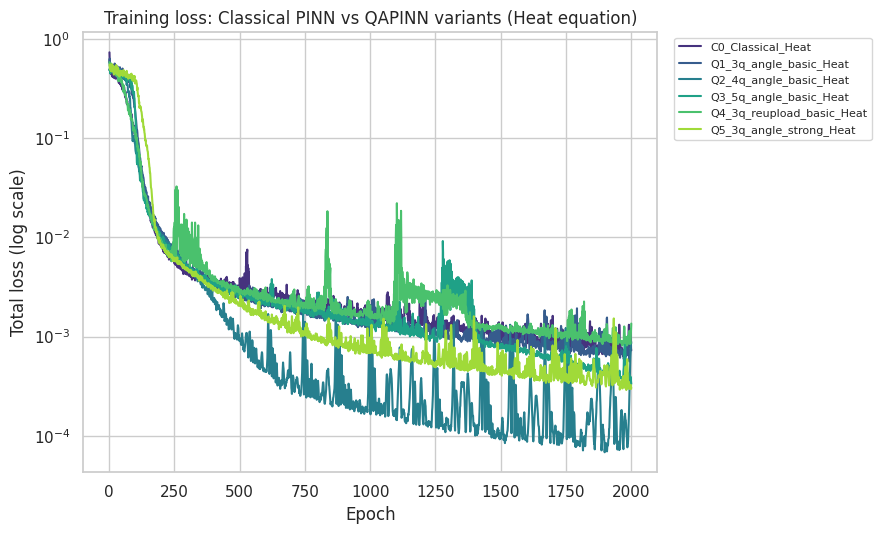

In [ ]:
# ============================================================
# Loss curves -- all experiments, log scale
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5.5))
for name, r in results.items():
    sns.lineplot(x=r["history"]["epoch"], y=r["history"]["total"], label=name, ax=ax, linewidth=1.5)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Total loss (log scale)")
ax.set_title("Training loss: Classical PINN vs QAPINN variants (Heat equation)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("heat_loss_curves.png", dpi=150)
plt.show()


**Reading the output:** given how smooth and linear this PDE is, expect faster, closer convergence across all
six curves than in Burgers'. If QAPINN variants still visibly plateau earlier than `C0` even here, that's a
stronger, more general version of the Burgers' finding (the effect isn't specific to a hard, nonlinear problem);
if the gap mostly disappears on this easier PDE, that's an equally valid, specific, and useful finding.


### Whole-Model Gradient Diagnostics
These plots track the evolution of gradient variance and total gradient norm throughout the training process for all configurations, providing insight into the optimization landscape.


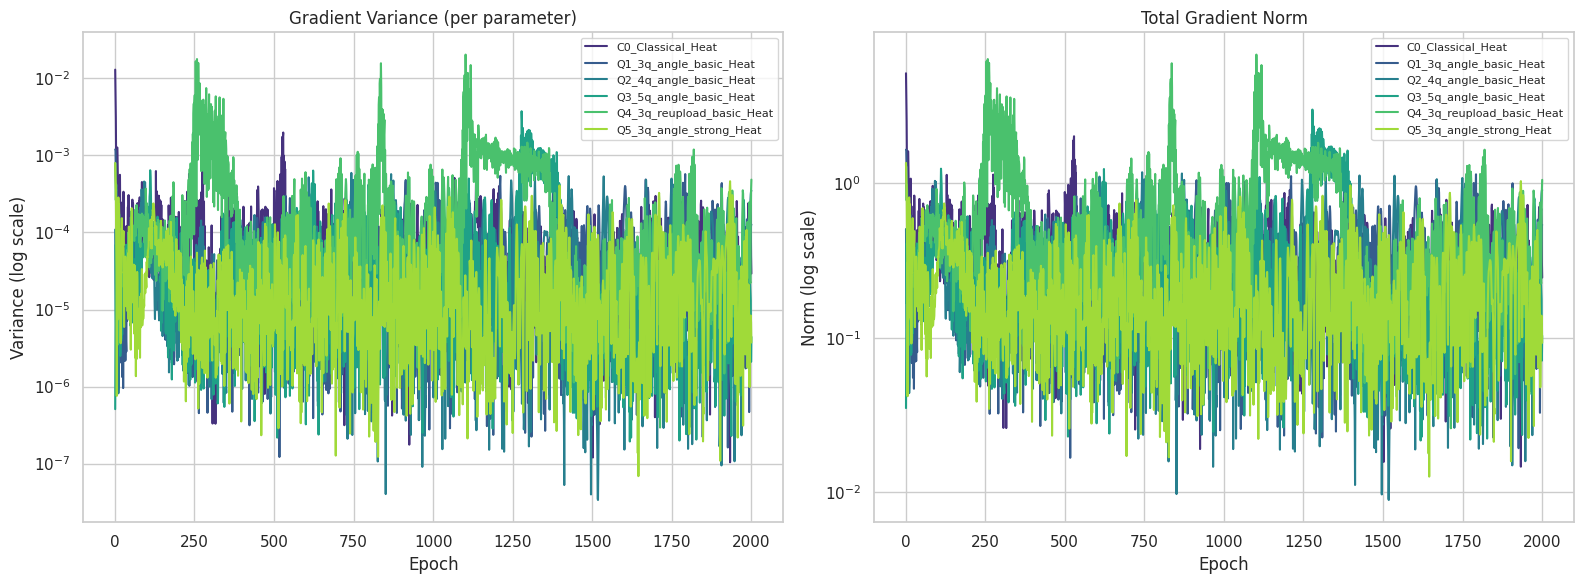

In [ ]:
# ============================================================
# Gradient diagnostics: Variance and Norm vs Epoch
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, r in results.items():
    sns.lineplot(x=r["history"]["epoch"], y=r["history"]["grad_variance"], label=name, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Gradient Variance (per parameter)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Variance (log scale)")
axes[0].legend(fontsize=8)

for name, r in results.items():
    sns.lineplot(x=r["history"]["epoch"], y=r["history"]["grad_norm"], label=name, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Total Gradient Norm")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Norm (log scale)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("heat_gradient_diagnostics.png", dpi=150)
plt.show()


**Reading the output:** as with Burgers', don't use this whole-model metric alone for claims about the quantum layer specifically -- see the isolated quantum-only version added later in this notebook.


### Comparative Analysis: Loss, Parameters, and Time
This cell generates bar charts comparing the three key performance indicators: the final training loss, the number of trainable parameters, and the total time required for training.


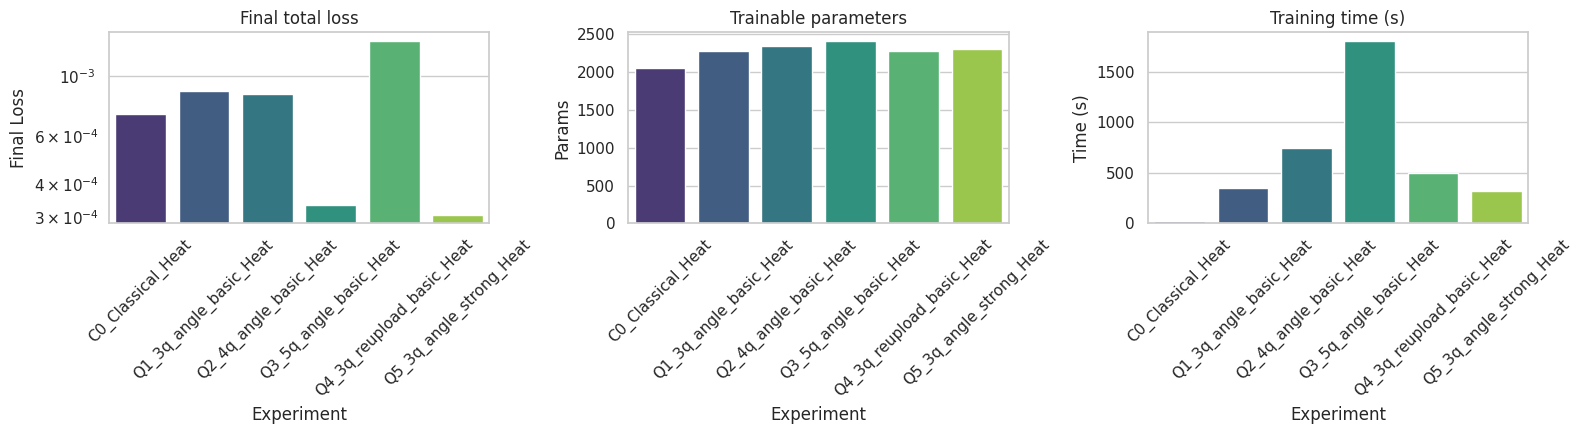

In [ ]:
# ============================================================
# Final loss, parameter count, and training time comparison
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.barplot(data=summary_df, x="Experiment", y="Final Loss", hue="Experiment", ax=axes[0], legend=False)
axes[0].set_yscale("log")
axes[0].set_title("Final total loss")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=summary_df, x="Experiment", y="Params", hue="Experiment", ax=axes[1], legend=False)
axes[1].set_title("Trainable parameters")
axes[1].tick_params(axis="x", rotation=45)

sns.barplot(data=summary_df, x="Experiment", y="Time (s)", hue="Experiment", ax=axes[2], legend=False)
axes[2].set_title("Training time (s)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("heat_comparison_bars.png", dpi=150)
plt.show()


**Reading the output:** the middle panel (params) should look roughly flat; the right panel (time) will show QAPINN taking longer, roughly increasing with qubit count, same pattern as Burgers'.


### XAI: Fourier Spectrum and McClean Barren-Plateau Scan
This comprehensive diagnostic block performs two tasks:
1. **Fourier Analysis**: Measures the expressivity of the models in the frequency domain.
2. **McClean Scan**: Measures the variance of the gradients at initialization to detect potential barren plateaus across different qubit counts.


--- 1. Generating Fourier Spectrum Plots ---


/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype complex128 requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


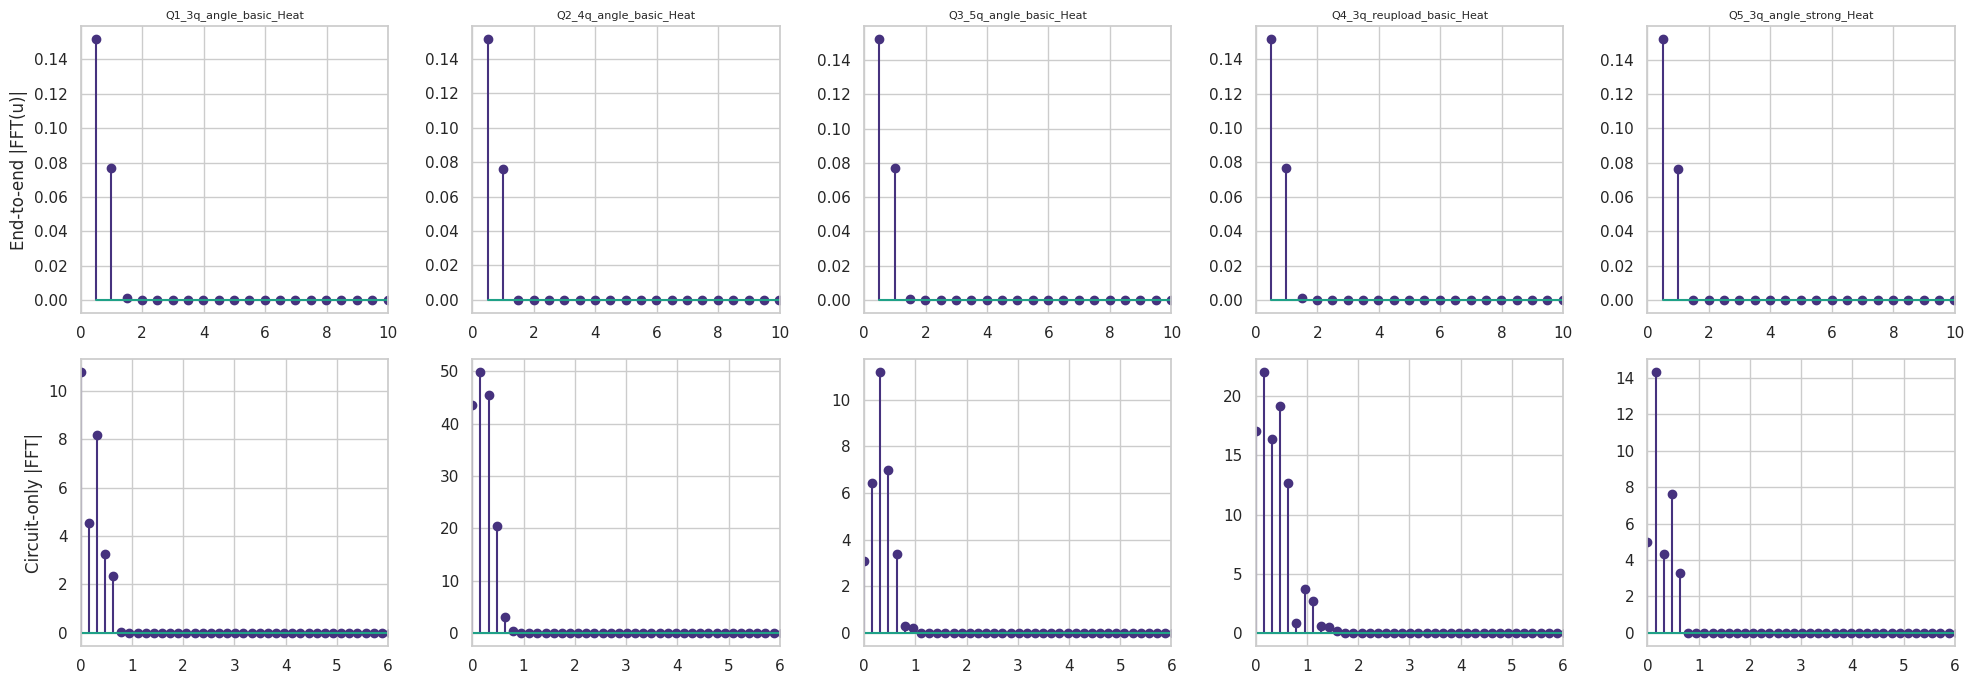

--- Circuit-only spectral summary (isolates VQC, swept angle) ---
               Experiment  Centroid   Spread  SignificantBins  MaxSignificantFreq
Q4_3q_reupload_basic_Heat  0.364590 0.311046                7            1.111856
   Q1_3q_angle_basic_Heat  0.221180 0.245040                5            0.635347
   Q2_4q_angle_basic_Heat  0.211982 0.184851                5            0.635347
   Q3_5q_angle_basic_Heat  0.332389 0.199177                5            0.635347
  Q5_3q_angle_strong_Heat  0.272024 0.204729                5            0.635347

--- 2. Running McClean-style gradient variance scan ---


/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype complex128 requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


               Experiment  McClean_Variance
   Q1_3q_angle_basic_Heat          0.224049
   Q2_4q_angle_basic_Heat          0.036860
   Q3_5q_angle_basic_Heat          0.045213
Q4_3q_reupload_basic_Heat          0.076514
  Q5_3q_angle_strong_Heat          0.086758


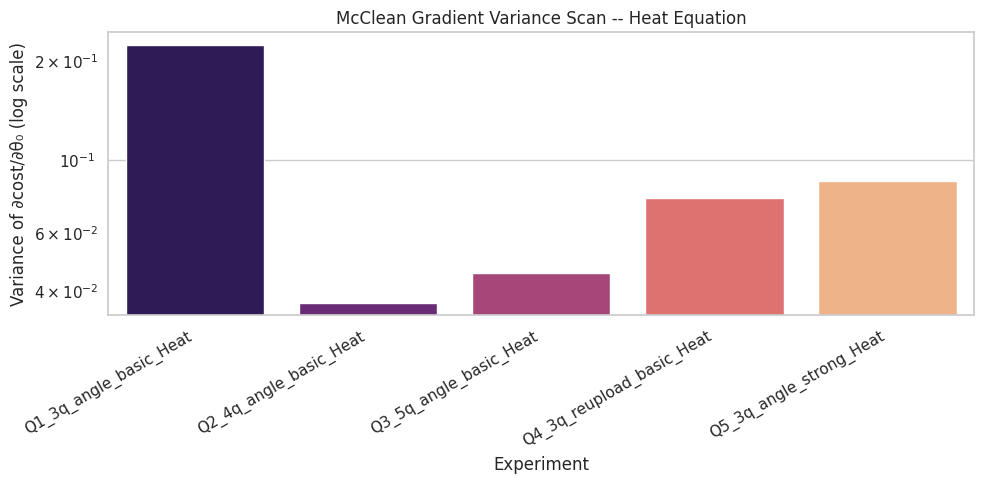

In [ ]:
# ============================================================
# XAI Suite: Fourier spectrum (corrected) + McClean barren-plateau
# scan, looped over all 5 QAPINN experiments.
# ============================================================
ALL_CONFIGS = {e["name"]: e for e in EXPERIMENTS}
loaded_models = {name: r["model"] for name, r in results.items()}


def end_to_end_spectrum(model, t_fixed=0.5, n_points=500):
    x_vals = torch.linspace(PHYSICS_CONFIG["x_min"], PHYSICS_CONFIG["x_max"], n_points).reshape(-1, 1)
    t_vals = torch.full((n_points, 1), t_fixed)
    model.eval()
    with torch.no_grad():
        u_pred = model(x_vals.to(GPU_DEVICE), t_vals.to(GPU_DEVICE)).cpu().numpy().flatten()
    u_pred_detrended = u_pred - np.mean(u_pred)
    window = np.hanning(n_points)
    fft_result = np.fft.fft(u_pred_detrended * window)
    frequencies = np.fft.fftfreq(n_points, d=(x_vals[1] - x_vals[0]).item())
    positive_freq_idx = frequencies > 0
    f_e2e = frequencies[positive_freq_idx]
    m_e2e = np.abs(fft_result[positive_freq_idx]) / n_points
    sort_idx = np.argsort(f_e2e)
    return f_e2e[sort_idx], m_e2e[sort_idx]


def circuit_only_spectrum(model, n_points=500):
    """Sweeps a coherent encoding angle theta in [-pi, pi] through the
    trained quantum layer and FFTs the resulting output -- the Schuld
    et al. test for a VQC's accessible Fourier spectrum."""
    if not hasattr(model, "quantum_layer"):
        return np.array([]), np.array([])
    n_qubits = model.n_qubits
    theta = np.linspace(-np.pi, np.pi, n_points)
    outputs = []
    model.eval()
    with torch.no_grad():
        for th in theta:
            inp = torch.full((1, n_qubits), th, dtype=torch.float32)
            out = model.quantum_layer(inp.cpu()).squeeze(0)
            outputs.append(out.mean().item())
    outputs = np.array(outputs)
    signal = outputs - outputs.mean()
    window = np.hanning(n_points)
    fft_result = np.fft.rfft(signal * window)
    frequencies = np.fft.rfftfreq(n_points, d=(theta[1] - theta[0]))
    return frequencies, np.abs(fft_result)


N_SAMPLES = 100

_MCCLEAN_GRAD_CACHE = {}

def _get_mcclean_grad_fn(n_qubits, n_qlayers, encoding, ansatz):
    """Cached, JIT-compiled JAX gradient function for the McClean-style scan
    below -- one compile per circuit architecture, reused across every
    sample and every seed that calls it (e.g. the seed-robustness sweep)."""
    key = (n_qubits, n_qlayers, encoding, ansatz)
    if key not in _MCCLEAN_GRAD_CACHE:
        qnode = build_qnode(n_qubits, n_qlayers, encoding, ansatz)
        # Non-zero fixed input -- an all-zero input makes AngleEmbedding the
        # identity gate, which would make "angle" and "reupload" encoding
        # produce the identical circuit (see markdown above).
        fixed_input = jnp.full((n_qubits,), 0.7854)  # pi/4

        def cost_fn(w):
            return jnp.sum(jnp.stack(qnode(fixed_input, w)))

        _MCCLEAN_GRAD_CACHE[key] = jax.jit(jax.grad(cost_fn))
    return _MCCLEAN_GRAD_CACHE[key]


def mcclean_variance_scan(n_qubits, n_qlayers, encoding, ansatz, n_samples=N_SAMPLES):
    weight_shape = (n_qlayers, n_qubits, 3) if ansatz == "strongly_entangling" else (n_qlayers, n_qubits)
    grad_fn = _get_mcclean_grad_fn(n_qubits, n_qlayers, encoding, ansatz)
    grads = []
    for _ in range(n_samples):
        # Weights are still drawn from torch's global RNG (torch.randn), so
        # SEED / torch.manual_seed(seed) continues to control this scan's
        # reproducibility exactly as before -- only the circuit evaluation
        # and its gradient now run through JAX.
        w = torch.randn(weight_shape)
        g = grad_fn(jnp.asarray(w.numpy()))
        grads.append(float(np.asarray(g).flatten()[0]))
    return float(np.var(grads)) if grads else 0.0


qapinn_names = [n for n, c in ALL_CONFIGS.items() if c["kind"] == "qapinn"]

print("--- 1. Generating Fourier Spectrum Plots ---")
fig, axes = plt.subplots(2, len(qapinn_names), figsize=(4 * len(qapinn_names), 7))
fourier_summary = []
for i, name in enumerate(qapinn_names):
    model = loaded_models[name]
    f_e2e, m_e2e = end_to_end_spectrum(model)
    axes[0, i].stem(f_e2e, m_e2e)
    axes[0, i].set_title(name, fontsize=8)
    axes[0, i].set_xlim(0, 10)

    f_c, m_c = circuit_only_spectrum(model)
    axes[1, i].stem(f_c, m_c)
    axes[1, i].set_xlim(0, 6)

    if m_c.sum() > 0:
        mag_norm = m_c / m_c.sum()
        centroid = float(np.sum(f_c * mag_norm))
        spread = float(np.sqrt(np.sum(((f_c - centroid) ** 2) * mag_norm)))
        n_sig = int(np.sum(m_c > 0.05 * m_c.max()))
        max_sig_freq = float(f_c[m_c > 0.05 * m_c.max()].max()) if n_sig > 0 else 0.0
    else:
        centroid = spread = n_sig = max_sig_freq = 0.0

    fourier_summary.append({
        "Experiment": name, "Centroid": centroid, "Spread": spread,
        "SignificantBins": n_sig, "MaxSignificantFreq": max_sig_freq,
    })

axes[0, 0].set_ylabel("End-to-end |FFT(u)|")
axes[1, 0].set_ylabel("Circuit-only |FFT|")
plt.tight_layout()
plt.savefig("heat_xai_fourier.png", dpi=150)
plt.show()

fourier_df = pd.DataFrame(fourier_summary).sort_values("MaxSignificantFreq", ascending=False)
print("--- Circuit-only spectral summary (isolates VQC, swept angle) ---")
print(fourier_df.to_string(index=False))

print("\n--- 2. Running McClean-style gradient variance scan ---")
mcclean_results = []
for name in qapinn_names:
    cfg = ALL_CONFIGS[name]
    var = mcclean_variance_scan(cfg["n_qubits"], 3, cfg["encoding"], cfg["ansatz"])
    mcclean_results.append({"Experiment": name, "McClean_Variance": var})

mcclean_df = pd.DataFrame(mcclean_results)
print(mcclean_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=mcclean_df, x="Experiment", y="McClean_Variance", hue="Experiment", palette="magma", legend=False)
plt.yscale("log")
plt.title("McClean Gradient Variance Scan -- Heat Equation")
plt.ylabel("Variance of ∂cost/∂θ₀ (log scale)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("heat_xai_mcclean.png", dpi=150)
plt.show()


**Reading the output:** compare `Q1` vs `Q3` (qubit-count axis) directly against the Burgers' notebook's
equivalent numbers -- since the circuits are architecturally identical, close agreement is strong evidence the
qubit-count trainability effect is a property of the QAPINN architecture itself, not specific to Burgers' PDE.
Also check whether any configuration combines a wide Fourier spectrum with a collapsed McClean variance --
that combination is the McClean-sense barren-plateau signature (expressive in theory, untrainable in practice).


### Weight-Init Scale Robustness
Specifically targeting the deeper Q5 configuration, this test checks if gradient behavior changes when the initialization range is widened, helping to distinguish between a robust barren plateau and a simple scaling artifact.


In [ ]:
# ============================================================
# Robustness check: Q5 McClean variance at two weight-init scales
# ============================================================
def mcclean_variance_robustness_test(n_qubits, n_qlayers, encoding, ansatz, scale=1.0, n_samples=100):
    # Reuses the same cached, JIT-compiled gradient function as the McClean
    # scan above (_get_mcclean_grad_fn) -- only the weight-draw scale differs.
    weight_shape = (n_qlayers, n_qubits, 3) if ansatz == "strongly_entangling" else (n_qlayers, n_qubits)
    grad_fn = _get_mcclean_grad_fn(n_qubits, n_qlayers, encoding, ansatz)
    grads = []
    for _ in range(n_samples):
        w = torch.randn(weight_shape) * scale
        g = grad_fn(jnp.asarray(w.numpy()))
        grads.append(float(np.asarray(g).flatten()[0]))
    return float(np.var(grads)) if grads else 0.0


q5_cfg = ALL_CONFIGS["Q5_3q_angle_strong_Heat"]

print("--- Robustness Check: Q5 Gradient Variance under Different Scalings ---")
var_standard = mcclean_variance_robustness_test(q5_cfg["n_qubits"], 3, q5_cfg["encoding"], q5_cfg["ansatz"], scale=1.0)
var_pi = mcclean_variance_robustness_test(q5_cfg["n_qubits"], 3, q5_cfg["encoding"], q5_cfg["ansatz"], scale=np.pi)

print(f"Q5 Variance (Scale=1.0): {var_standard:.2e}")
print(f"Q5 Variance (Scale=PI):  {var_pi:.2e}")

if var_pi < 1e-12 and var_standard < 1e-12:
    print("\nRESULT: Gradient collapse persists under wide initialization. Robust barren plateau.")
elif abs(var_pi - var_standard) / max(var_standard, 1e-12) < 2.0:
    print("\nRESULT: Variance is consistent across both scales (whether collapsed or not) -- not an init-scale artifact.")
else:
    print(f"\nRESULT: Variance changed substantially with scale ({var_standard:.2e} -> {var_pi:.2e}) -- treat any collapse as scale-dependent, not a robust barren plateau.")


--- Robustness Check: Q5 Gradient Variance under Different Scalings ---
Q5 Variance (Scale=1.0): 1.04e-01
Q5 Variance (Scale=PI):  1.00e-01

RESULT: Variance is consistent across both scales (whether collapsed or not) -- not an init-scale artifact.


**Reading the output:** consistent results across both scales -- whether collapsed or normal -- rules out initialization range as the explanation either way. Don't claim a barren plateau (or its absence) is robust without this check.


### Cross-Seed Robustness Scan
To ensure the gradient variance findings are general, this block repeats the McClean scan across five additional random seeds and visualizes the results using box plots.


Q1_3q_angle_basic_Heat       | mean=2.351e-01 | std=3.554e-02 | min=1.862e-01 | max=2.657e-01
Q2_4q_angle_basic_Heat       | mean=3.373e-02 | std=3.406e-03 | min=2.801e-02 | max=3.811e-02
Q3_5q_angle_basic_Heat       | mean=3.165e-02 | std=4.840e-03 | min=2.296e-02 | max=3.751e-02
Q4_3q_reupload_basic_Heat    | mean=7.373e-02 | std=1.421e-02 | min=5.054e-02 | max=9.287e-02
Q5_3q_angle_strong_Heat      | mean=8.715e-02 | std=8.031e-03 | min=7.412e-02 | max=9.899e-02


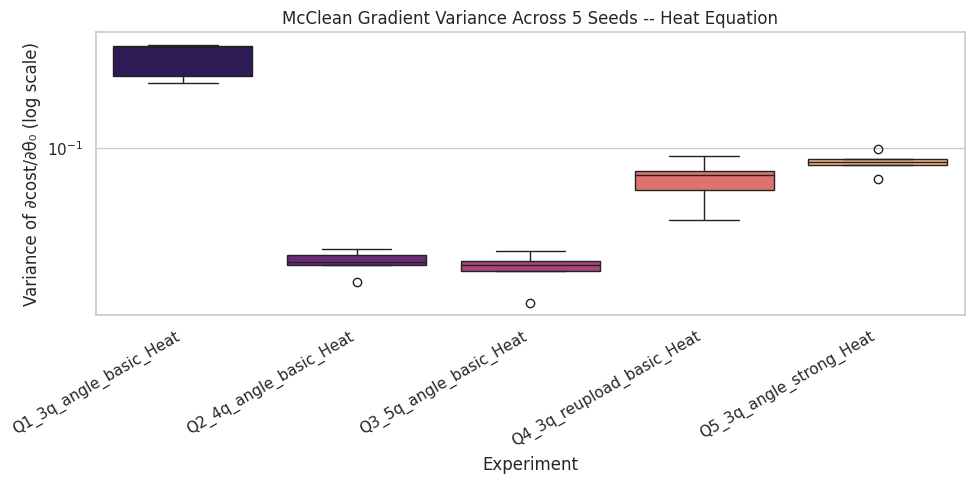


--- Seed-robustness summary ---
                               mean       std       min       max
Experiment                                                       
Q1_3q_angle_basic_Heat     0.235097  0.039733  0.186171  0.265731
Q2_4q_angle_basic_Heat     0.033733  0.003808  0.028014  0.038108
Q3_5q_angle_basic_Heat     0.031647  0.005412  0.022962  0.037509
Q4_3q_reupload_basic_Heat  0.073732  0.015891  0.050540  0.092866
Q5_3q_angle_strong_Heat    0.087147  0.008979  0.074121  0.098991


In [ ]:
# ============================================================
# Seed-robustness check for the McClean gradient variance scan,
# across ALL 5 QAPINN configs.
# ============================================================
ROBUSTNESS_SEEDS = [11, 29, 47, 71, 97]

seed_robustness_results = []
for name in qapinn_names:
    cfg = ALL_CONFIGS[name]
    seed_vars = []
    for seed in ROBUSTNESS_SEEDS:
        torch.manual_seed(seed)
        var = mcclean_variance_scan(cfg["n_qubits"], 3, cfg["encoding"], cfg["ansatz"])
        seed_vars.append(var)
        seed_robustness_results.append({"Experiment": name, "Seed": seed, "McClean_Variance": var})

    seed_vars = np.array(seed_vars)
    print(f"{name:28s} | mean={seed_vars.mean():.3e} | std={seed_vars.std():.3e} | "
          f"min={seed_vars.min():.3e} | max={seed_vars.max():.3e}")

torch.manual_seed(SEED)  # restore the global seed

seed_robustness_df = pd.DataFrame(seed_robustness_results)

plt.figure(figsize=(10, 5))
sns.boxplot(data=seed_robustness_df, x="Experiment", y="McClean_Variance",
            hue="Experiment", palette="magma", legend=False)
plt.yscale("log")
plt.title(f"McClean Gradient Variance Across {len(ROBUSTNESS_SEEDS)} Seeds -- Heat Equation")
plt.ylabel("Variance of ∂cost/∂θ₀ (log scale)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("heat_xai_mcclean_seed_robustness.png", dpi=150)
plt.show()

seed_summary_df = seed_robustness_df.groupby("Experiment")["McClean_Variance"].agg(["mean", "std", "min", "max"])
print("\n--- Seed-robustness summary ---")
print(seed_summary_df.to_string())


**Reading the output:** compare this mean/std table directly against the Burgers' notebook's equivalent -- per-config agreement here is the clearest cross-PDE generalization evidence in this project.


### XAI: Spatial Activation Maps
This visualization maps the mean activation of the first hidden layer (or quantum layer) across the $(x, t)$ domain, revealing how the model internalizes the spatial and temporal decay of the heat equation.


/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype complex128 requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


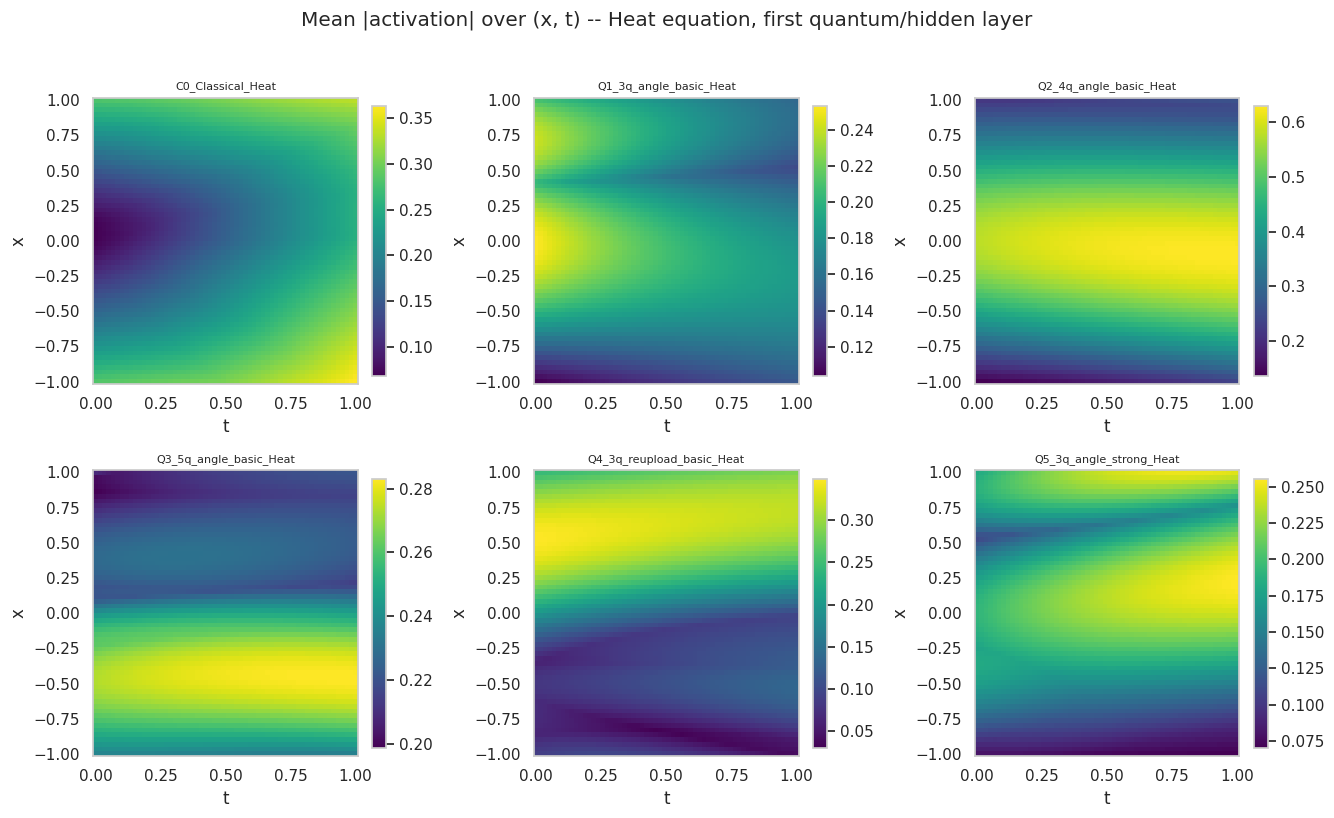

--- Activation map summary (sorted by spatial variability) ---
               Experiment  MeanActivation  StdActivation  MaxActivation  CoeffOfVariation
Q4_3q_reupload_basic_Heat        0.185308       0.104807       0.349528          0.565584
   Q2_4q_angle_basic_Heat        0.446319       0.134616       0.629372          0.301613
        C0_Classical_Heat        0.221750       0.063010       0.363315          0.284148
  Q5_3q_angle_strong_Heat        0.179814       0.047735       0.255646          0.265469
   Q1_3q_angle_basic_Heat        0.184372       0.027982       0.252815          0.151767
   Q3_5q_angle_basic_Heat        0.243826       0.024007       0.283150          0.098458


In [ ]:
# ============================================================
# Activation maps: mean |activation| over (x, t) grid
# ============================================================
def get_activation_map(model, kind, n_grid=60, device=GPU_DEVICE):
    x_vals = torch.linspace(PHYSICS_CONFIG["x_min"], PHYSICS_CONFIG["x_max"], n_grid)
    t_vals = torch.linspace(PHYSICS_CONFIG["t_min"], PHYSICS_CONFIG["t_max"], n_grid)
    xx, tt = torch.meshgrid(x_vals, t_vals, indexing="ij")
    x_flat = xx.reshape(-1, 1).to(device)
    t_flat = tt.reshape(-1, 1).to(device)

    captured = {}
    def hook(mod, inp, out):
        captured["val"] = out.detach().cpu()

    if kind == "qapinn":
        handle = model.quantum_layer.register_forward_hook(hook)
    else:
        handle = model.net[1].register_forward_hook(hook)

    model.eval()
    with torch.no_grad():
        _ = model(x_flat, t_flat)
    handle.remove()

    act = captured["val"]
    mean_act = act.abs().mean(dim=1).reshape(n_grid, n_grid).numpy()
    return xx.numpy(), tt.numpy(), mean_act


n_models = len(ALL_CONFIGS)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
axes = axes.flatten()

activation_summary = []
for i, (name, cfg) in enumerate(ALL_CONFIGS.items()):
    model = loaded_models[name]
    xx, tt, act_map = get_activation_map(model, cfg["kind"])

    im = axes[i].pcolormesh(tt, xx, act_map, shading="auto", cmap="viridis")
    axes[i].set_title(name, fontsize=8)
    axes[i].set_xlabel("t")
    axes[i].set_ylabel("x")
    plt.colorbar(im, ax=axes[i], fraction=0.046)

    activation_summary.append({
        "Experiment": name,
        "MeanActivation": float(act_map.mean()),
        "StdActivation": float(act_map.std()),
        "MaxActivation": float(act_map.max()),
        "CoeffOfVariation": float(act_map.std() / (act_map.mean() + 1e-12)),
    })

for j in range(len(ALL_CONFIGS), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mean |activation| over (x, t) -- Heat equation, first quantum/hidden layer", y=1.02)
plt.tight_layout()
plt.savefig("heat_xai_activation_maps.png", dpi=150)
plt.show()

activation_df = pd.DataFrame(activation_summary).sort_values("CoeffOfVariation", ascending=False)
print("--- Activation map summary (sorted by spatial variability) ---")
print(activation_df.to_string(index=False))


**Reading the output:** unlike Burgers', don't expect or require sharp x-dependent banding here -- the exact solution itself is smooth and x-symmetric. A configuration whose map looks flat/uninformative in *both* x and t is the real red flag on this PDE, since even a poorly-trained model should at least capture the basic time-decay.


### Absolute Weight Scale Assessment
This block simply reports the final standard deviation and norm of the quantum weights to provide a basic sense of parameter magnitude after training.


In [ ]:
# ============================================================
# Quick weight-scale check (scale only, see caveat above)
# ============================================================
for name in qapinn_names:
    model = loaded_models[name]
    final_w = dict(model.quantum_layer.named_parameters())["weights"].detach()
    print(f"{name}: final weight std={final_w.std().item():.4f}, final weight norm={final_w.norm().item():.4f}")


Q1_3q_angle_basic_Heat: final weight std=1.9985, final weight norm=13.9633
Q2_4q_angle_basic_Heat: final weight std=2.1099, final weight norm=13.5073
Q3_5q_angle_basic_Heat: final weight std=1.6895, final weight norm=16.6203
Q4_3q_reupload_basic_Heat: final weight std=1.6104, final weight norm=13.8233
Q5_3q_angle_strong_Heat: final weight std=1.7371, final weight norm=19.7583



### Standalone Weight Movement Test
To determine if the quantum layer is actively learning, this cell retrains a fresh Q5 model and measures the 'delta' between the initial and final weights. A low relative change would indicate the layer is effectively frozen.


### Definitive Weight-Movement Check for Q5 (Standalone Retrain with Logged Initialization)

Same method as the Burgers' notebook: a fresh `Q5` instance, weights logged before and after training, to
directly test whether the quantum layer's parameters actually moved. Given the heat equation's smoothness, a
healthy result here (meaningful weight movement) would be a useful contrast if Burgers' `Q5` showed minimal
movement -- it would suggest the earlier finding was PDE-difficulty-dependent, not architectural.

In [ ]:
# ============================================================
# Definitive weight-movement check for Q5
# ============================================================
q5_model = QAPINN(n_qubits=3, n_qlayers=4, classical_hidden=(25, 25, 25, 25),
                   encoding="angle", ansatz="strongly_entangling")
q5_model.to(GPU_DEVICE)

init_w = dict(q5_model.quantum_layer.named_parameters())["weights"].detach().clone()
print(f"Init weight norm: {init_w.norm().item():.4f}")

history, elapsed = train(q5_model, epochs=TRAIN_CONFIG["epochs"], device=GPU_DEVICE, log_every=10)

final_w = dict(q5_model.quantum_layer.named_parameters())["weights"].detach().clone()
print(f"Final weight norm: {final_w.norm().item():.4f}")

delta = (final_w - init_w).norm().item()
rel_change = delta / init_w.norm().item()
print(f"Weight delta norm: {delta:.4f} | relative change: {rel_change:.2%}")

if rel_change < 0.05:
    print("Weights barely moved (<5% relative change) -- consistent with an untrained/frozen circuit.")
else:
    print("Weights moved meaningfully -- the quantum layer participated actively in training on this PDE.")


Init weight norm: 23.3528
[   0.2s] Epoch     1/2000 | total=0.595012 pde=0.000003 ic=0.538048 bc=0.056962 | grad_var=1.24e-03 | q_var=7.24e-06
[   1.5s] Epoch    10/2000 | total=0.556902 pde=0.000002 ic=0.550410 bc=0.006490 | grad_var=7.07e-05 | q_var=6.05e-06
[   2.9s] Epoch    20/2000 | total=0.457755 pde=0.000044 ic=0.457300 bc=0.000411 | grad_var=3.47e-06 | q_var=1.82e-05
[   4.3s] Epoch    30/2000 | total=0.463312 pde=0.000112 ic=0.461722 bc=0.001478 | grad_var=1.42e-05 | q_var=2.77e-05
[   5.7s] Epoch    40/2000 | total=0.439660 pde=0.000454 ic=0.426661 bc=0.012545 | grad_var=2.82e-05 | q_var=7.47e-05
[   7.5s] Epoch    50/2000 | total=0.477995 pde=0.001349 ic=0.413229 bc=0.063417 | grad_var=7.25e-06 | q_var=6.54e-05
[   9.6s] Epoch    60/2000 | total=0.414659 pde=0.001474 ic=0.343475 bc=0.069710 | grad_var=2.65e-05 | q_var=1.07e-04
[  11.1s] Epoch    70/2000 | total=0.390097 pde=0.002532 ic=0.328922 bc=0.058642 | grad_var=8.46e-06 | q_var=9.71e-05
[  12.5s] Epoch    80/2000 | t

**Reading the output:** this is a fresh, differently-seeded run -- its `final_loss` won't exactly match the
official `Q5` row in `summary_df` and shouldn't be cited as if it does; only the weight-delta finding should be
quoted from this cell. Compare the relative-change percentage directly against Burgers' equivalent number.


### Final Gradient Variance Comparison
This plot summarizes the gradient variance of all models at the very end of their training cycles, serving as a final diagnostic of the trained optimization state.


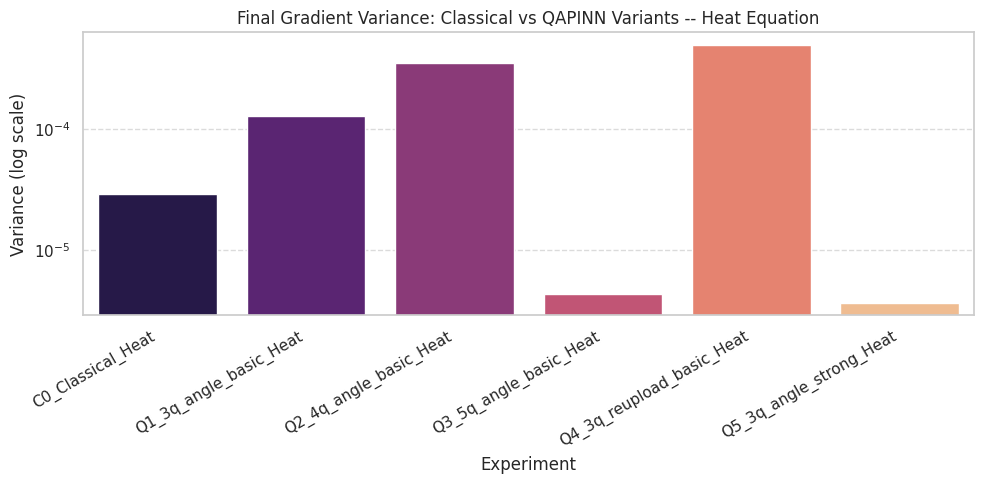

In [ ]:
# ============================================================
# Comparison of Final Gradient Variance (whole-model)
# ============================================================
final_vars = []
for name, r in results.items():
    final_vars.append({"Experiment": name, "Final Gradient Variance": r["history"]["grad_variance"][-1]})
final_var_df = pd.DataFrame(final_vars)

plt.figure(figsize=(10, 5))
sns.barplot(data=final_var_df, x="Experiment", y="Final Gradient Variance", hue="Experiment", palette="magma", legend=False)
plt.yscale("log")
plt.title("Final Gradient Variance: Classical vs QAPINN Variants -- Heat Equation")
plt.ylabel("Variance (log scale)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("heat_final_grad_variance.png", dpi=150)
plt.show()


**Reading the output:** whole-model metric, mixes classical and quantum gradients -- don't use alone for quantum-specific claims.


### Isolated Quantum-Layer Gradient Tracking
Unlike the whole-model plots, this cell focuses exclusively on the gradients within the quantum layer throughout the training process, offering a clearer view of quantum-specific trainability.


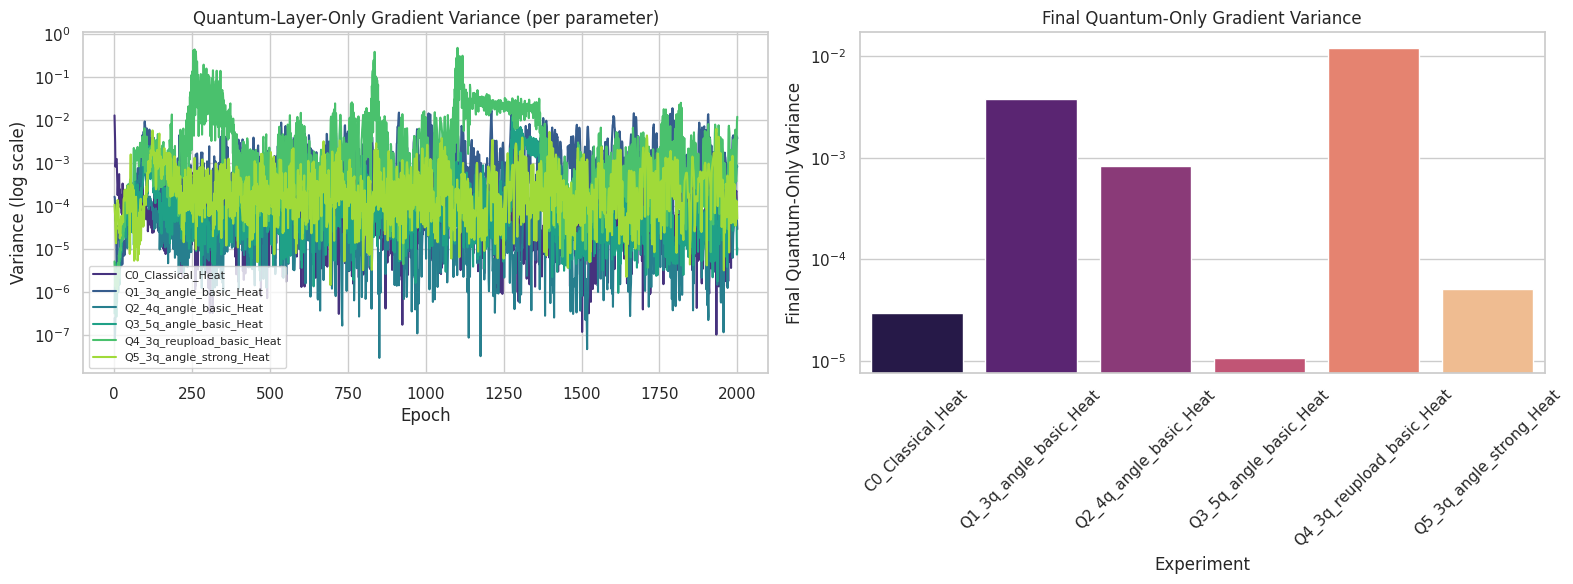

               Experiment  Final Quantum-Only Variance
        C0_Classical_Heat                     0.000029
   Q1_3q_angle_basic_Heat                     0.003794
   Q2_4q_angle_basic_Heat                     0.000830
   Q3_5q_angle_basic_Heat                     0.000011
Q4_3q_reupload_basic_Heat                     0.012091
  Q5_3q_angle_strong_Heat                     0.000051


In [ ]:
# ============================================================
# Quantum-layer-only gradient variance across training
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, r in results.items():
    sns.lineplot(x=r["history"]["epoch"], y=r["history"]["quantum_grad_variance"], label=name, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Quantum-Layer-Only Gradient Variance (per parameter)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Variance (log scale)")
axes[0].legend(fontsize=8)

final_q_vars = pd.DataFrame([
    {"Experiment": name, "Final Quantum-Only Variance": r["history"]["quantum_grad_variance"][-1]}
    for name, r in results.items() if "quantum_grad_variance" in r["history"]
])
sns.barplot(data=final_q_vars, x="Experiment", y="Final Quantum-Only Variance",
            hue="Experiment", palette="magma", legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Final Quantum-Only Gradient Variance")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("heat_quantum_only_grad_variance.png", dpi=150)
plt.show()

print(final_q_vars.to_string(index=False))


**Reading the output:** cross-reference against the McClean scan (Cell 11) -- agreement between the two, computed completely differently, is stronger evidence than either alone. Also directly comparable to Burgers' equivalent numbers per configuration.


### Optimized Classical Baseline (C0-Best)
To provide a high-water mark for accuracy, this cell trains a larger classical PINN (with more hidden units and a longer epoch budget) to compare against the parameter-matched QAPINNs.


In [ ]:
# ============================================================
# Classical-Best baseline
# ============================================================
classical_best_cfg = dict(name="C0_Best_Classical_Heat", kind="classical")

def run_classical_best(cfg, epochs=EPOCHS_CLASSICAL_BEST):
    print("=" * 80)
    print(f"Running {cfg['name']} ({epochs} epochs)")
    print("=" * 80)
    model = ClassicalPINN(layers=(2, 40, 40, 40, 40, 1))
    history, elapsed = train(model, epochs=epochs, device=GPU_DEVICE, log_every=max(100, epochs // 5))
    torch.save(model.state_dict(), f"{cfg['name']}.pt")
    return {
        "name": cfg["name"], "qubits": "-", "encoding": "-", "ansatz": "-",
        "params": model.num_params(), "final_loss": history["total"][-1],
        "time_s": elapsed, "history": history, "model": model,
    }

results["C0_Best_Classical_Heat"] = run_classical_best(classical_best_cfg)

summary_df = pd.DataFrame([
    {"Experiment": r["name"], "Qubits": r["qubits"], "Encoding": r["encoding"],
     "Ansatz": r["ansatz"], "Params": r["params"],
     "Final Loss": r["final_loss"], "Time (s)": round(r["time_s"], 2)}
    for r in results.values()
])
summary_df.to_csv("qapinn_heat_results.csv", index=False)
summary_df


Running C0_Best_Classical_Heat (5000 epochs)
[   0.1s] Epoch     1/5000 | total=0.656189 pde=0.023194 ic=0.604585 bc=0.028410 | grad_var=4.27e-03 | q_var=4.27e-03
[  12.4s] Epoch  1000/5000 | total=0.001464 pde=0.000479 ic=0.000553 bc=0.000433 | grad_var=3.98e-05 | q_var=3.98e-05
[  24.8s] Epoch  2000/5000 | total=0.000645 pde=0.000295 ic=0.000073 bc=0.000277 | grad_var=2.34e-05 | q_var=2.34e-05
[  37.0s] Epoch  3000/5000 | total=0.000339 pde=0.000219 ic=0.000050 bc=0.000070 | grad_var=2.11e-07 | q_var=2.11e-07
[  49.1s] Epoch  4000/5000 | total=0.000262 pde=0.000171 ic=0.000023 bc=0.000069 | grad_var=1.75e-06 | q_var=1.75e-06
[  61.1s] Epoch  5000/5000 | total=0.000213 pde=0.000137 ic=0.000021 bc=0.000055 | grad_var=8.53e-07 | q_var=8.53e-07
Done in 61.07s



,Experiment,Qubits,Encoding,Ansatz,Params,Final Loss,Time (s)
0,C0_Classical_Heat,-,-,-,2051,0.000727,24.93
1,Q1_3q_angle_basic_Heat,3,angle,basic_entangler,2283,0.000881,348.55
2,Q2_4q_angle_basic_Heat,4,angle,basic_entangler,2345,0.000859,751.08
3,Q3_5q_angle_basic_Heat,5,angle,basic_entangler,2407,0.000334,1801.02
4,Q4_3q_reupload_basic_Heat,3,reupload,basic_entangler,2283,0.001353,494.53
5,Q5_3q_angle_strong_Heat,3,angle,strongly_entangling,2307,0.000307,325.12
6,C0_Best_Classical_Heat,-,-,-,5081,0.000213,61.07


**Reading the output:** compare `C0_Best_Classical_Heat`'s loss against both `C0_Classical_Heat` and the QAPINN rows, using the same Decision Rules framework as the Burgers' notebook (reproduced in Notes at the end).


### Accuracy Benchmarking vs. Exact Solution
This is the definitive test: every model is evaluated against the analytical exact solution using Mean Squared Error (MSE), Relative L2 Error, and Maximum Error metrics.


In [ ]:
# ============================================================
# Accuracy benchmark against the exact solution
# ============================================================
def get_reference_solution(nx=200, nt=100):
    x = np.linspace(PHYSICS_CONFIG["x_min"], PHYSICS_CONFIG["x_max"], nx)
    t = np.linspace(PHYSICS_CONFIG["t_min"], PHYSICS_CONFIG["t_max"], nt)
    XX, TT = np.meshgrid(x, t)

    x_torch = torch.tensor(XX.flatten(), dtype=torch.float32).reshape(-1, 1).to(GPU_DEVICE)
    t_torch = torch.tensor(TT.flatten(), dtype=torch.float32).reshape(-1, 1).to(GPU_DEVICE)
    u_ref_torch = exact_solution(x_torch, t_torch)

    return x_torch, t_torch, XX, TT, u_ref_torch


def calculate_metrics(model, x_ref, t_ref, u_ref_vals):
    model.eval()
    with torch.no_grad():
        u_pred = model(x_ref, t_ref).cpu().numpy().flatten()
    u_ref = u_ref_vals.detach().cpu().numpy().flatten()

    mse = np.mean((u_ref - u_pred) ** 2)
    l2_rel = np.linalg.norm(u_ref - u_pred) / np.linalg.norm(u_ref)
    max_err = np.max(np.abs(u_ref - u_pred))
    return mse, l2_rel, max_err


x_torch, t_torch, XX, TT, u_reference = get_reference_solution()

final_metrics = []
for name, r in results.items():
    mse, l2_rel, max_err = calculate_metrics(r["model"], x_torch, t_torch, u_reference)
    final_metrics.append({
        "Experiment": name, "Rel L2 Error": f"{l2_rel:.4e}", "Max Error": f"{max_err:.4e}",
        "PDE Loss": f"{r['history']['pde'][-1]:.4e}", "Params": r["params"],
        "Time (s)": round(r["time_s"], 2),
        "Q-Variance": f"{r['history']['quantum_grad_variance'][-1]:.2e}" if "quantum_grad_variance" in r["history"] else "-",
    })

benchmark_df = pd.DataFrame(final_metrics)
benchmark_df


/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype complex128 requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


,Experiment,Rel L2 Error,Max Error,PDE Loss,Params,Time (s),Q-Variance
0,C0_Classical_Heat,2.5528e-02,2.9218e-02,3.6364e-04,2051,24.93,2.93e-05
1,Q1_3q_angle_basic_Heat,1.9271e-02,2.2675e-02,3.8831e-04,2283,348.55,3.79e-03
2,Q2_4q_angle_basic_Heat,2.8534e-02,2.2183e-02,6.1928e-05,2345,751.08,8.30e-04
3,Q3_5q_angle_basic_Heat,1.0586e-02,1.7299e-02,1.8767e-04,2407,1801.02,1.07e-05
4,Q4_3q_reupload_basic_Heat,2.9824e-02,3.3770e-02,3.4415e-04,2283,494.53,1.21e-02
5,Q5_3q_angle_strong_Heat,6.2335e-03,1.1113e-02,2.2079e-04,2307,325.12,5.12e-05
6,C0_Best_Classical_Heat,3.8645e-03,1.2330e-02,1.3688e-04,5081,61.07,8.53e-07


**Reading the output:** given how smooth this PDE is, expect much lower Rel L2 error across the board than
Burgers' -- both classical baselines and QAPINN variants should fit this well. If QAPINN's error is still
noticeably higher than classical's even here, that's stronger evidence the gap is architectural (related to the
quantum layer itself) rather than driven by problem difficulty.

**Decision-rule reference (same as the Burgers' notebook):**

| Rule | Condition | Conclusion |
|---|---|---|
| 1 | QAPINN beats **both** `C0_Classical_Heat` and `C0_Best_Classical_Heat` | Strong evidence for a genuinely useful quantum configuration |
| 2 | QAPINN beats only `C0_Classical_Heat` (parameter-matched) | Evidence for parameter efficiency, not best achievable accuracy |
| 3 | QAPINN has lower training loss but higher Rel L2 Error | Not a solution-quality win -- investigate loss weighting/imbalance |
| 4 | QAPINN is less accurate and slower | Report as a negative result, honestly |
| 5 | More qubits/depth improve accuracy but cost grows rapidly | Report the accuracy-cost trade-off, not a free advantage |
| 6 | Result varies a lot across seeds | Report as unstable/inconclusive |


### Pointwise Error Distribution
This cell visualizes exactly where the model's predictions deviate from the exact solution across the $(x, t)$ grid, helping to identify if errors are concentrated at the initial state or during the diffusion process.


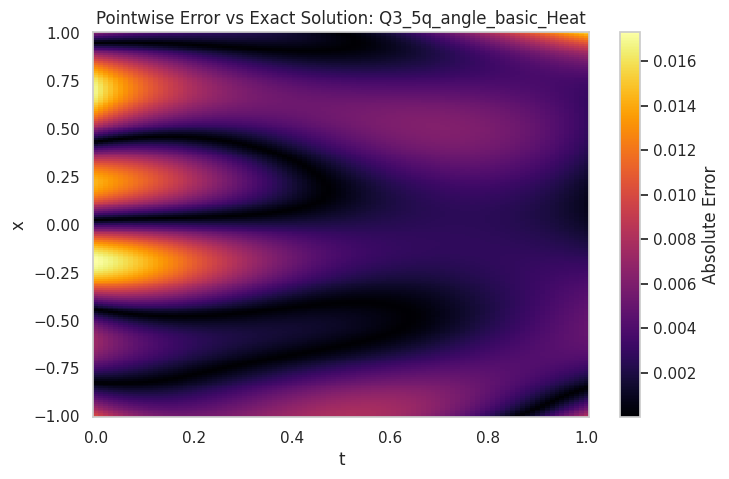

In [ ]:
# ============================================================
# Pointwise error map
# ============================================================
target_q = "Q3_5q_angle_basic_Heat"
model_q = results[target_q]["model"]

with torch.no_grad():
    u_q = model_q(x_torch, t_torch).cpu().numpy().reshape(XX.shape)
u_ref_plot = u_reference.cpu().numpy().reshape(XX.shape)
error_map = np.abs(u_ref_plot - u_q)

plt.figure(figsize=(8, 5))
plt.pcolormesh(TT, XX, error_map, cmap="inferno", shading="auto")
plt.colorbar(label="Absolute Error")
plt.title(f"Pointwise Error vs Exact Solution: {target_q}")
plt.xlabel("t")
plt.ylabel("x")
plt.show()


**Reading the output:** unlike Burgers' (where error concentrates near the shock), expect error here to be
more evenly distributed, or concentrated near `t=0` if the model struggles to match the initial condition
precisely -- there's no shock region to act as a natural error hotspot on this smoother PDE.

### Notes

- **Full parity with the Burgers' notebook**: every component listed as missing from the earlier lean version is
  now present -- the full 6-config matrix, `C0_Best_Classical_Heat`, whole-model and quantum-only gradient
  diagnostics, both Fourier and McClean XAI techniques (with the zero-input fix applied from the start), the
  weight-init-scale and 5-seed robustness checks, activation maps, the weight-movement check, the exact-solution
  accuracy benchmark, Stage C multi-seed statistics with Welch's t-test and Bonferroni correction, and the
  pointwise error map.
- **Cross-notebook comparison is the main added value of this notebook**: `Q1`-`Q5`'s circuits are identical
  across Burgers', Navier-Stokes, and this notebook. Put the McClean scan results from all three side by side in
  your report -- agreement is the strongest generalization evidence available from this project; disagreement is
  equally worth reporting, as evidence the effect is PDE-dependent.
- **Reproducibility scope**: the main matrix and most diagnostics are `SEED=42` single-seed; Stage C (if enabled)
  adds 5 further seeds for the accuracy metric specifically.
- **Exact-solution verification**: checked symbolically with SymPy before this notebook was written -- the PDE,
  initial condition, and both boundary conditions all reduce to exactly zero when the exact solution is
  substituted in.
- **Local CPU support**: `FAST_LOCAL_MODE`, `EPOCHS_MAIN`/`EPOCHS_CLASSICAL_BEST`, `RUN_STAGE_C`, and the Runtime
  Calibration cell all carry over the same CPU-backup design used for Burgers' and Navier-Stokes -- this single
  notebook works on both a Colab GPU and a local CPU-only machine without modification.
- **Quantum backend**: the quantum circuit runs on PennyLane's JAX interface (`interface="jax"`, JIT-compiled via
  `jax.jit`/`jax.vmap`) instead of the torch interface, bridged into the PyTorch training loop through a small
  custom `torch.autograd.Function` (`JaxQuantumLayer`) that supports the multi-order differentiation a PINN needs
  (`u_xx`, then weight gradients through it). Verified against the original torch-interface circuit before this
  notebook was edited -- forward pass, `u_x`, `u_xx`, and weight gradients all matched to float32 precision across
  all five `Q1`-`Q5` configurations. Compiled circuits are cached per architecture, so Stage C's multi-seed sweep
  pays the JIT compile cost once per config, not once per seed.

**Report checklist** -- evidence gathered in this notebook, mapped to typical report sections:

- *Experiments*: `summary_df` -- final loss, parameter count, training time, all 7 configurations.
- *Results (accuracy)*: `benchmark_df` (single-seed) + Stage C `rel_l2_summary`/significance table (multi-seed,
  if enabled) -- both against the true exact solution.
- *Explainability §1 (expressivity)*: circuit-only Fourier spectrum, `fourier_df`.
- *Explainability §2 (trainability)*: McClean scan, scale-robustness check, 5-seed cross-config robustness check,
  quantum-only gradient variance plot, weight-movement check.
- *Explainability §3 (what was learned)*: activation maps + pointwise error map.
- *Cross-PDE generalization*: side-by-side McClean/Fourier comparison against the Burgers' and Navier-Stokes
  notebooks for identical `Q1`-`Q5` architectures.
- *Limitations*: single-seed default, Bonferroni caveat if Stage C is run, `C0_Best_Classical_Heat`'s different
  epoch budget, CPU/GPU training-time gap.